# Installs

In [1]:
!pip -q install datasets sentence-transformers hdbscan umap-learn psutil tqdm

# Imports

In [2]:
import os
import gc
import re
import json
import math
import time
import psutil
import random
import warnings
from dataclasses import dataclass
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
from sklearn.preprocessing import normalize
from sklearn.random_projection import SparseRandomProjection
from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    Birch,
    AgglomerativeClustering,
    SpectralClustering,
    DBSCAN
)
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception as e:
    HDBSCAN_AVAILABLE = False
    print("HDBSCAN not available:", e)

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

# Config

In [3]:
USE_SENTENCE_EMBEDDINGS = False
WIKI_CONFIG = "20231101.en"
MAX_ARTICLES = 12000
EVAL_ARTICLES_SMALL = 2500
MIN_WORDS = 120
MAX_WORDS = 450
MAX_FEATURES = 50000

JL_DIMS = [128, 256, 512, 1024]
PAIR_SAMPLE_SIZE = 5000

LSH_BITS = 128
LSH_BANDS = 32
LSH_BAND_SIZE = LSH_BITS // LSH_BANDS

N_DUPLICATES = 1200
N_HARD_NEGATIVES = 500
TOPK_RETRIEVAL = [1, 5, 10]

TOPIC_KEYWORDS = {
    "science_space": [
        "space", "planet", "galaxy", "astronomy", "satellite", "nasa", "orbit", "cosmos"
    ],
    "history_war": [
        "war", "battle", "empire", "king", "dynasty", "military", "kingdom", "historical"
    ],
    "sports": [
        "football", "cricket", "basketball", "olympic", "tennis", "league", "tournament", "sport"
    ],
    "technology": [
        "computer", "software", "internet", "algorithm", "technology", "network", "digital", "programming"
    ],
    "biology_medicine": [
        "species", "genus", "disease", "medical", "biology", "protein", "cell", "organism"
    ],
    "geography_places": [
        "city", "river", "mountain", "district", "province", "village", "country", "geography"
    ],
}


# Helper Functions

In [4]:
def memory_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)

def clean_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\[[^\]]+\]", " ", text)
    text = text.replace("\xa0", " ").strip()
    return text

def tokenize_words(text: str):
    return re.findall(r"[A-Za-z][A-Za-z\-']+", text.lower())

def clip_text_by_words(text: str, min_words=MIN_WORDS, max_words=MAX_WORDS):
    words = tokenize_words(text)
    if len(words) < min_words:
        return None
    words = words[:max_words]
    return " ".join(words)

def assign_topic(text: str):
    t = text.lower()
    scores = {}
    for topic, kws in TOPIC_KEYWORDS.items():
        scores[topic] = sum(kw in t for kw in kws)
    best_topic, best_score = max(scores.items(), key=lambda x: x[1])
    return best_topic if best_score > 0 else "other"

def text_memory_bytes(texts):
    return sum(len(t.encode("utf-8")) for t in texts)

def vector_memory_bytes(X):
    if hasattr(X, "data") and hasattr(X, "indptr"):
        return X.data.nbytes + X.indices.nbytes + X.indptr.nbytes
    return X.nbytes

def safe_intrinsic_metrics(X_dense, labels):
    labels = np.asarray(labels)
    uniq = np.unique(labels)
    if len(uniq) < 2:
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }
    try:
        sil = silhouette_score(X_dense, labels, metric="euclidean")
    except Exception:
        sil = np.nan
    try:
        db = davies_bouldin_score(X_dense, labels)
    except Exception:
        db = np.nan
    try:
        ch = calinski_harabasz_score(X_dense, labels)
    except Exception:
        ch = np.nan
    return {
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch
    }

def purity_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    N = len(y_true)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0:
            continue
        _, counts = np.unique(y_true[idx], return_counts=True)
        total += counts.max()
    return total / max(N, 1)

def connected_components(n, edges):
    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, j in edges:
        union(i, j)

    roots = np.array([find(i) for i in range(n)])
    _, labels = np.unique(roots, return_inverse=True)
    return labels

def sample_pair_indices(n, m=PAIR_SAMPLE_SIZE, seed=42):
    rng = np.random.default_rng(seed)
    a = rng.integers(0, n, size=m)
    b = rng.integers(0, n, size=m)
    return a, b

def exact_cosine_similarity_sparse_rows(X, idx_a, idx_b):
    vals = []
    for i, j in zip(idx_a, idx_b):
        vals.append(X[i].multiply(X[j]).sum())
    return np.asarray(vals)

def plot_bar(df, x, y, title, ylabel=None, rot=25, figsize=(9, 4)):
    plt.figure(figsize=figsize)
    plt.bar(df[x].astype(str), df[y])
    plt.xticks(rotation=rot, ha="right")
    plt.title(title)
    plt.ylabel(ylabel if ylabel else y)
    plt.tight_layout()
    plt.show()

def save_df(df, path):
    df.to_csv(path, index=False)
    return path

# Load Wikipedia

In [5]:
print("=" * 80)
print("Loading Wikipedia dataset...")
print("=" * 80)

t0 = time.perf_counter()
wiki = load_dataset("wikimedia/wikipedia", WIKI_CONFIG, split="train")
load_time = time.perf_counter() - t0

print(f"Loaded Wikipedia config: {WIKI_CONFIG}")
print(f"Rows available: {len(wiki)}")
print(f"Load time: {load_time:.2f} sec")
print(f"Memory after load: {memory_mb():.2f} MB")

wiki = wiki.shuffle(seed=42).select(range(MAX_ARTICLES * 2))

titles, texts, topic_labels = [], [], []
for row in tqdm(wiki, desc="Cleaning and filtering articles"):
    title = clean_text(row["title"])
    text = clean_text(row["text"])
    text = clip_text_by_words(text, min_words=MIN_WORDS, max_words=MAX_WORDS)
    if text is None:
        continue
    topic = assign_topic(title + " " + text)
    if topic == "other":
        continue
    titles.append(title)
    texts.append(text)
    topic_labels.append(topic)
    if len(texts) >= MAX_ARTICLES:
        break

df_articles = pd.DataFrame({
    "doc_id": np.arange(len(texts)),
    "title": titles,
    "text": texts,
    "topic": topic_labels,
})

topic_to_id = {t: i for i, t in enumerate(sorted(df_articles["topic"].unique()))}
df_articles["topic_id"] = df_articles["topic"].map(topic_to_id)

print("\nCorpus summary")
print(df_articles["topic"].value_counts())
print(f"Final usable articles: {len(df_articles)}")
print(f"Text memory (MB): {text_memory_bytes(df_articles['text'].tolist()) / (1024**2):.2f}")

Loading Wikipedia dataset...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

20231101.en/train-00000-of-00041.parquet:   0%|          | 0.00/420M [00:00<?, ?B/s]

20231101.en/train-00001-of-00041.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/6407814 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/41 [00:00<?, ?it/s]

Loaded Wikipedia config: 20231101.en
Rows available: 6407814
Load time: 384.10 sec
Memory after load: 2417.19 MB


Cleaning and filtering articles:   0%|          | 0/24000 [00:00<?, ?it/s]


Corpus summary
topic
history_war         6556
geography_places    2003
sports              1804
biology_medicine     660
technology           497
science_space        480
Name: count, dtype: int64
Final usable articles: 12000
Text memory (MB): 24.28


# Synthetic Near-Duplicate Generation

In [6]:
STOPWORDS_SMALL = {
    "the", "a", "an", "of", "to", "in", "and", "for", "on", "at", "by", "from", "with", "is", "was"
}

def duplicate_transform_easy(text, seed):
    rng = random.Random(seed)
    words = text.split()

    kept = []
    for w in words:
        lw = w.lower()
        if lw in STOPWORDS_SMALL and rng.random() < 0.35:
            continue
        if rng.random() < 0.08:
            continue
        kept.append(w)

    if len(kept) > 30:
        for _ in range(max(1, len(kept) // 80)):
            pos = rng.randint(0, len(kept) - 1)
            kept.insert(pos, kept[pos])

    text2 = " ".join(kept)
    sents = re.split(r"(?<=[.!?])\s+", text2)
    if len(sents) >= 3 and rng.random() < 0.8:
        idxs = list(range(len(sents)))
        i = rng.randint(0, len(idxs)-2)
        idxs[i], idxs[i+1] = idxs[i+1], idxs[i]
        sents = [sents[k] for k in idxs]
    return " ".join(sents)

def duplicate_transform_medium(text, seed):
    rng = random.Random(seed)
    words = text.split()

    out = []
    for w in words:
        if rng.random() < 0.14:
            continue
        out.append(w)

    repl = {
        "city": "urban area",
        "country": "nation",
        "computer": "computing system",
        "war": "conflict",
        "species": "organism",
        "river": "waterway",
        "software": "program",
        "planet": "world",
        "history": "historical record",
        "football": "soccer"
    }
    out2 = []
    for w in out:
        key = re.sub(r"[^A-Za-z]", "", w).lower()
        if key in repl and rng.random() < 0.35:
            out2.extend(repl[key].split())
        else:
            out2.append(w)

    if len(out2) > 50:
        for start in range(0, len(out2), 25):
            window = out2[start:start+8]
            rng.shuffle(window)
            out2[start:start+8] = window

    return " ".join(out2)

def duplicate_transform_hard(text, seed):
    rng = random.Random(seed)
    words = text.split()

    kept = [w for w in words if rng.random() > 0.22]
    if len(kept) < 40:
        kept = words[:]

    for start in range(0, len(kept), 20):
        block = kept[start:start+10]
        rng.shuffle(block)
        kept[start:start+10] = block

    if len(kept) > 20:
        extras = rng.sample(kept, k=min(6, max(2, len(kept)//60)))
        insert_positions = sorted(rng.sample(range(len(kept)), k=len(extras)))
        offset = 0
        for pos, token in zip(insert_positions, extras):
            kept.insert(pos + offset, token)
            offset += 1
    return " ".join(kept)

def build_duplicate_benchmark(df, n_dups=N_DUPLICATES):
    rng = np.random.default_rng(42)
    n = min(n_dups, len(df))
    base_idx = rng.choice(df.index.values, size=n, replace=False)

    dup_rows = []
    for k, idx in enumerate(base_idx):
        text = df.loc[idx, "text"]
        title = df.loc[idx, "title"]
        topic = df.loc[idx, "topic"]
        if k % 3 == 0:
            dup_text = duplicate_transform_easy(text, seed=1000 + k)
            hardness = "easy"
        elif k % 3 == 1:
            dup_text = duplicate_transform_medium(text, seed=1000 + k)
            hardness = "medium"
        else:
            dup_text = duplicate_transform_hard(text, seed=1000 + k)
            hardness = "hard"
        dup_rows.append({
            "source_doc_id": int(df.loc[idx, "doc_id"]),
            "source_title": title,
            "topic": topic,
            "dup_text": dup_text,
            "hardness": hardness
        })
    return pd.DataFrame(dup_rows)

dup_df = build_duplicate_benchmark(df_articles)
print(f"\nGenerated duplicates: {len(dup_df)}")
print(dup_df["hardness"].value_counts())


Generated duplicates: 1200
hardness
easy      400
medium    400
hard      400
Name: count, dtype: int64


# TF-IDF Features

In [7]:
print("\n" + "=" * 80)
print("Building TF-IDF features...")
print("=" * 80)

t0 = time.perf_counter()
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9
)
X_tfidf = vectorizer.fit_transform(df_articles["text"])
X_tfidf = normalize(X_tfidf, norm="l2", axis=1)
tfidf_time = time.perf_counter() - t0

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"TF-IDF build time: {tfidf_time:.2f} sec")
print(f"TF-IDF memory (MB): {vector_memory_bytes(X_tfidf) / (1024**2):.2f}")

X_dup_tfidf = vectorizer.transform(dup_df["dup_text"])
X_dup_tfidf = normalize(X_dup_tfidf, norm="l2", axis=1)


Building TF-IDF features...
TF-IDF shape: (12000, 50000)
TF-IDF build time: 18.63 sec
TF-IDF memory (MB): 19.93


# Semantic Embeddings

In [8]:
if USE_SENTENCE_EMBEDDINGS:
    print("\nBuilding sentence embeddings...")
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    X_sent = model.encode(df_articles["text"].tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    X_dup_sent = model.encode(dup_df["dup_text"].tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    print("Sentence embedding shape:", X_sent.shape)
else:
    X_sent = None
    X_dup_sent = None

# JL Validation Across Multiple Dimensions


JL validation...
   jl_dim  jl_time_sec  mean_abs_distortion  median_abs_distortion  \
0     128     0.198058             0.067827               0.053837   
1     256     0.391766             0.048316               0.039310   
2     512     0.765036             0.034042               0.027684   
3    1024     0.938859             0.024824               0.020659   

   p95_abs_distortion  max_abs_distortion_sample  jl_memory_mb  
0            0.179635                   0.416175      11.71875  
1            0.124698                   0.318430      23.43750  
2            0.085904                   0.237062      46.87500  
3            0.061508                   0.140167      93.75000  


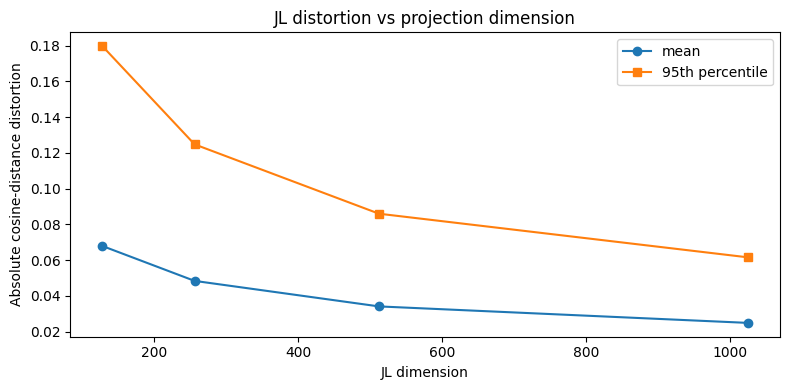

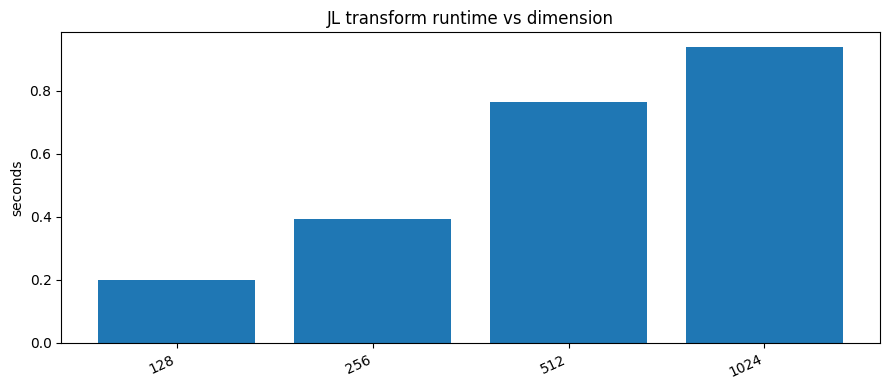

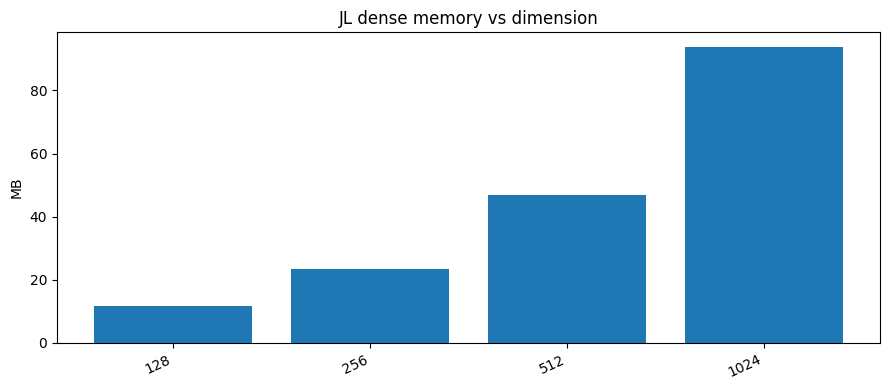

Using JL dimension 512 for main comparisons


In [9]:
print("\n" + "=" * 80)
print("JL validation...")
print("=" * 80)

jl_outputs = {}
jl_rows = []

idx_a, idx_b = sample_pair_indices(X_tfidf.shape[0], m=PAIR_SAMPLE_SIZE, seed=42)
orig_sim = exact_cosine_similarity_sparse_rows(X_tfidf, idx_a, idx_b)
orig_dist = 1.0 - orig_sim

for jl_dim in JL_DIMS:
    rp = SparseRandomProjection(
        n_components=jl_dim,
        dense_output=True,
        random_state=42
    )

    t0 = time.perf_counter()
    X_jl = rp.fit_transform(X_tfidf)
    jl_time = time.perf_counter() - t0
    X_jl = normalize(X_jl, norm="l2", axis=1)

    X_dup_jl = rp.transform(X_dup_tfidf)
    X_dup_jl = normalize(X_dup_jl, norm="l2", axis=1)

    jl_sim = np.sum(X_jl[idx_a] * X_jl[idx_b], axis=1)
    jl_dist = 1.0 - jl_sim
    abs_distortion = np.abs(jl_dist - orig_dist)

    jl_outputs[jl_dim] = (X_jl, X_dup_jl)

    jl_rows.append({
        "jl_dim": jl_dim,
        "jl_time_sec": jl_time,
        "mean_abs_distortion": abs_distortion.mean(),
        "median_abs_distortion": np.median(abs_distortion),
        "p95_abs_distortion": np.quantile(abs_distortion, 0.95),
        "max_abs_distortion_sample": abs_distortion.max(),
        "jl_memory_mb": vector_memory_bytes(X_jl) / (1024**2),
    })

jl_df = pd.DataFrame(jl_rows)
print(jl_df)

plt.figure(figsize=(8, 4))
plt.plot(jl_df["jl_dim"], jl_df["mean_abs_distortion"], marker="o", label="mean")
plt.plot(jl_df["jl_dim"], jl_df["p95_abs_distortion"], marker="s", label="95th percentile")
plt.xlabel("JL dimension")
plt.ylabel("Absolute cosine-distance distortion")
plt.title("JL distortion vs projection dimension")
plt.legend()
plt.tight_layout()
plt.show()

plot_bar(jl_df, "jl_dim", "jl_time_sec", "JL transform runtime vs dimension", ylabel="seconds")
plot_bar(jl_df, "jl_dim", "jl_memory_mb", "JL dense memory vs dimension", ylabel="MB")

MAIN_JL_DIM = 512 if 512 in jl_outputs else JL_DIMS[len(JL_DIMS)//2]
X_jl_main, X_dup_jl_main = jl_outputs[MAIN_JL_DIM]
print(f"Using JL dimension {MAIN_JL_DIM} for main comparisons")

# LSH Implementations

In [21]:
def random_hyperplane_hash(X, hyperplanes):
    proj = X @ hyperplanes.T
    return proj >= 0.0

def bits_to_int(bit_row):
    out = 0
    for b in bit_row:
        out = (out << 1) | int(b)
    return out

def lsh_candidate_buckets(bits, band_size):
    n, n_bits = bits.shape
    assert n_bits % band_size == 0
    n_bands = n_bits // band_size

    tables = []
    for b in range(n_bands):
        start = b * band_size
        end = start + band_size
        table = defaultdict(list)
        for i in range(n):
            key = bits_to_int(bits[i, start:end])
            table[key].append(i)
        tables.append(table)
    return tables

def build_candidate_pairs(tables, max_bucket_size=300):
    cand = set()
    for table in tables:
        for _, idxs in table.items():
            if len(idxs) < 2:
                continue
            if len(idxs) > max_bucket_size:
                continue
            for i, j in combinations(idxs, 2):
                cand.add((min(i, j), max(i, j)))
    return cand

def lsh_build_graph(X, cosine_threshold=0.45, n_bits=LSH_BITS, band_size=LSH_BAND_SIZE, max_bucket_size=300, seed=42):
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    hyperplanes = rng.normal(size=(n_bits, d)).astype(np.float32)
    hyperplanes /= np.linalg.norm(hyperplanes, axis=1, keepdims=True) + 1e-12

    t0 = time.perf_counter()
    bits = random_hyperplane_hash(X, hyperplanes)
    tables = lsh_candidate_buckets(bits, band_size=band_size)
    cand_pairs = build_candidate_pairs(tables, max_bucket_size=max_bucket_size)
    mid = time.perf_counter()

    edges = []
    for i, j in cand_pairs:
        sim = float(np.dot(X[i], X[j]))
        if sim >= cosine_threshold:
            edges.append((i, j))

    labels = connected_components(n=X.shape[0], edges=edges)
    total = time.perf_counter() - t0

    out = {
        "bits": bits,
        "tables": tables,
        "candidate_pairs": cand_pairs,
        "edges": edges,
        "labels": labels,
        "hash_time_sec": mid - t0,
        "refine_time_sec": total - (mid - t0),
        "total_time_sec": total,
        "n_candidates": len(cand_pairs),
        "n_edges": len(edges),
        "n_clusters": len(np.unique(labels))
    }
    return out

def lsh_query_candidates(query_vec, hyperplanes, tables, band_size):
    q_bits = random_hyperplane_hash(query_vec.reshape(1, -1), hyperplanes)[0]
    n_bands = len(tables)
    cand = set()
    for b in range(n_bands):
        start = b * band_size
        end = start + band_size
        key = bits_to_int(q_bits[start:end])
        for idx in tables[b].get(key, []):
            cand.add(idx)
    return list(cand), q_bits

def build_lsh_index_for_retrieval(X, n_bits=LSH_BITS, band_size=LSH_BAND_SIZE, seed=42):
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    hyperplanes = rng.normal(size=(n_bits, d)).astype(np.float32)
    hyperplanes /= np.linalg.norm(hyperplanes, axis=1, keepdims=True) + 1e-12
    bits = random_hyperplane_hash(X, hyperplanes)
    tables = lsh_candidate_buckets(bits, band_size=band_size)
    return {"hyperplanes": hyperplanes, "tables": tables, "bits": bits}

def lsh_retrieve_topk(X, index, Q, topk=10, band_size=LSH_BAND_SIZE, max_candidates=3000):
    hyperplanes = index["hyperplanes"]
    tables = index["tables"]
    retrieved = []
    query_times = []
    candidate_sizes = []

    for q in tqdm(Q, desc=f"LSH retrieval top-{topk}"):
        t0 = time.perf_counter()
        cand, _ = lsh_query_candidates(q, hyperplanes, tables, band_size)
        if len(cand) == 0:
            sims = np.dot(X, q)
            ids = np.argsort(-sims)[:topk]
        else:
            if len(cand) > max_candidates:
                cand = cand[:max_candidates]
            sims = X[cand] @ q
            order = np.argsort(-sims)[:topk]
            ids = np.array(cand)[order]
        query_times.append(time.perf_counter() - t0)
        candidate_sizes.append(len(cand))
        retrieved.append(ids.tolist())
    return retrieved, query_times, candidate_sizes

# Exact Retrieval Baselines

In [22]:
print("\n" + "=" * 80)
print("Exact retrieval baselines...")
print("=" * 80)

t0 = time.perf_counter()
nn_exact_sparse = NearestNeighbors(metric="cosine", algorithm="brute")
nn_exact_sparse.fit(X_tfidf)
fit_exact_sparse_time = time.perf_counter() - t0

t0 = time.perf_counter()
nn_exact_jl = NearestNeighbors(metric="cosine", algorithm="brute")
nn_exact_jl.fit(X_jl_main)
fit_exact_jl_time = time.perf_counter() - t0

print(f"Exact sparse index fit time: {fit_exact_sparse_time:.4f} sec")
print(f"Exact JL index fit time: {fit_exact_jl_time:.4f} sec")



Exact retrieval baselines...
Exact sparse index fit time: 0.0047 sec
Exact JL index fit time: 0.0054 sec


# Retrieval Evaluation on Planted Duplicates


Duplicate retrieval evaluation...


LSH retrieval top-10:   0%|          | 0/1200 [00:00<?, ?it/s]

                   method  topk    recall  avg_query_time_ms  avg_candidates
0  Exact cosine on TF-IDF     1  0.999167           1.359578         12000.0
1      Exact cosine on JL     1  1.000000           0.652539         12000.0
2      JL + LSH retrieval     1  0.111667           8.158244          1200.0
3  Exact cosine on TF-IDF     5  1.000000           1.359578         12000.0
4      Exact cosine on JL     5  1.000000           0.652539         12000.0
5      JL + LSH retrieval     5  0.111667           8.158244          1200.0
6  Exact cosine on TF-IDF    10  1.000000           1.359578         12000.0
7      Exact cosine on JL    10  1.000000           0.652539         12000.0
8      JL + LSH retrieval    10  0.111667           8.158244          1200.0


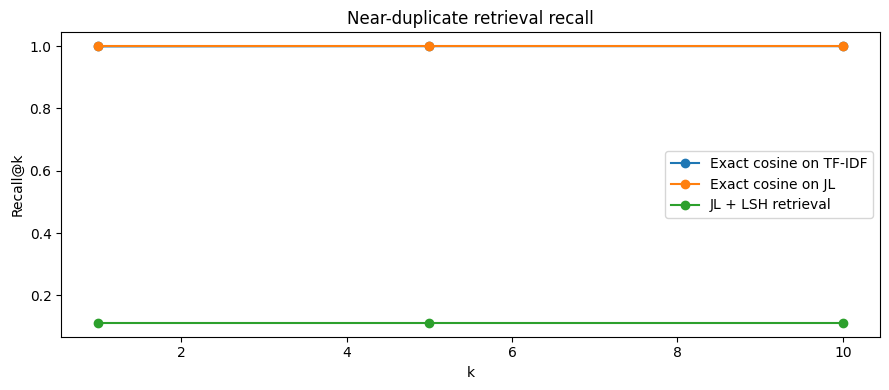

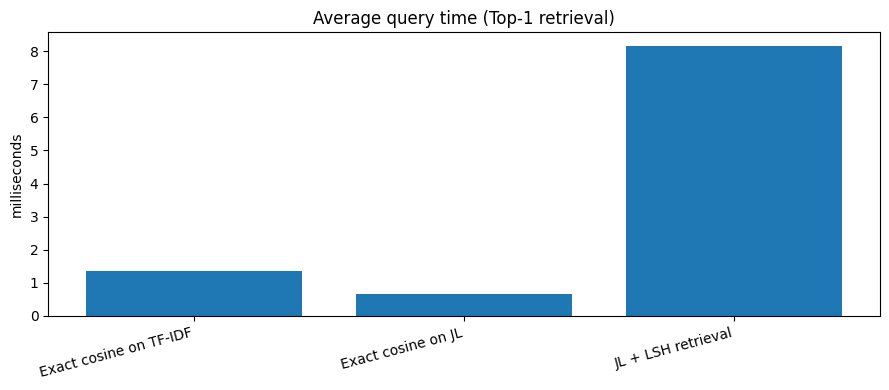

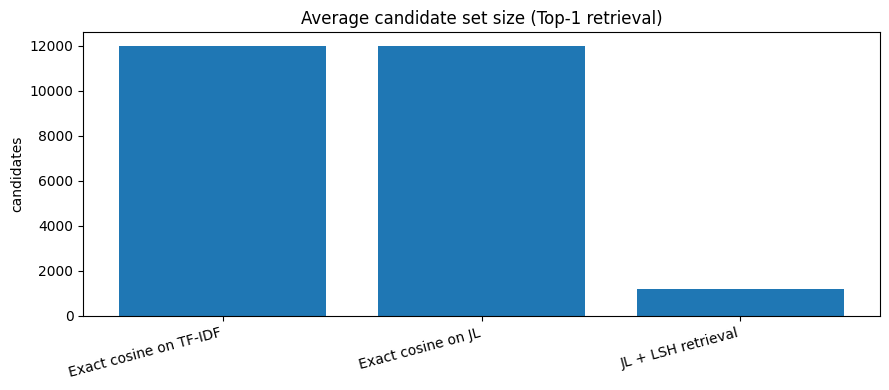


Recall by duplicate hardness
   hardness              method  topk  recall
0      easy  Exact cosine on JL     1   1.000
1      easy  JL + LSH retrieval     1   0.120
2      easy  Exact cosine on JL     5   1.000
3      easy  JL + LSH retrieval     5   0.120
4      easy  Exact cosine on JL    10   1.000
5      easy  JL + LSH retrieval    10   0.120
6    medium  Exact cosine on JL     1   1.000
7    medium  JL + LSH retrieval     1   0.100
8    medium  Exact cosine on JL     5   1.000
9    medium  JL + LSH retrieval     5   0.100
10   medium  Exact cosine on JL    10   1.000
11   medium  JL + LSH retrieval    10   0.100
12     hard  Exact cosine on JL     1   1.000
13     hard  JL + LSH retrieval     1   0.115
14     hard  Exact cosine on JL     5   1.000
15     hard  JL + LSH retrieval     5   0.115
16     hard  Exact cosine on JL    10   1.000
17     hard  JL + LSH retrieval    10   0.115


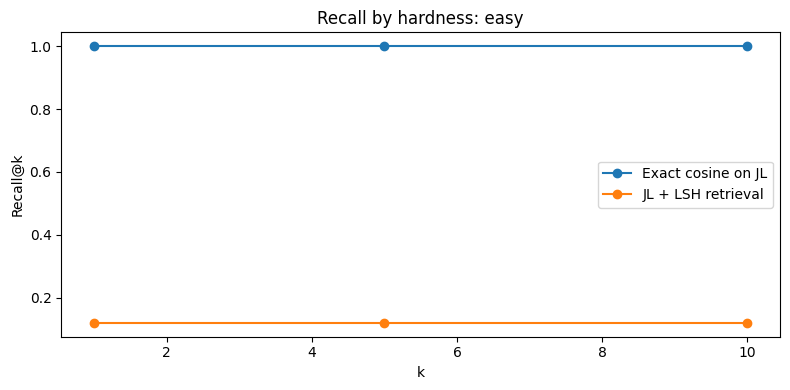

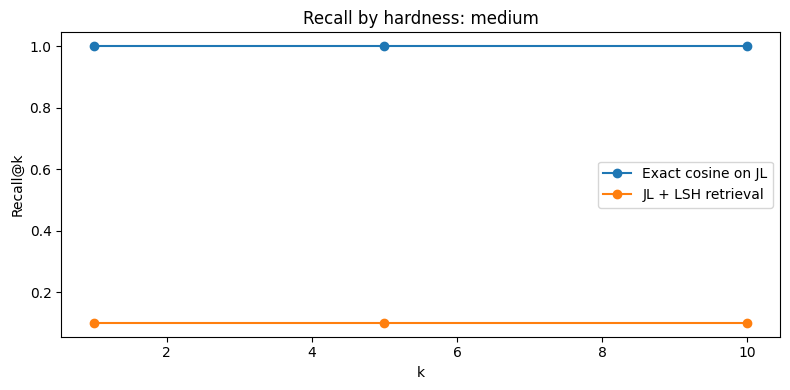

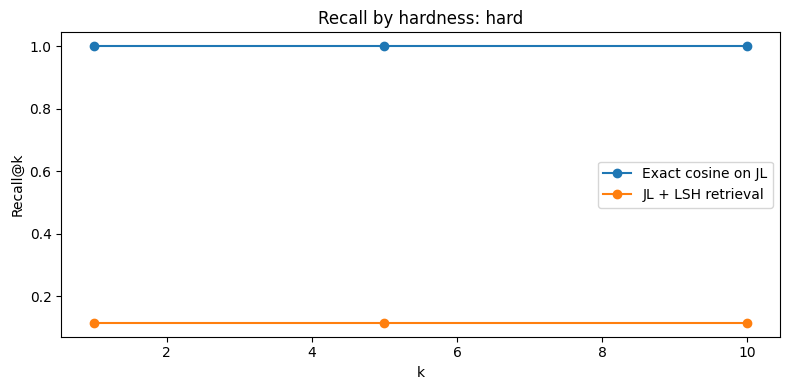

In [23]:
print("\n" + "=" * 80)
print("Duplicate retrieval evaluation...")
print("=" * 80)

t0 = time.perf_counter()
dist_sparse, ind_sparse = nn_exact_sparse.kneighbors(X_dup_tfidf, n_neighbors=max(TOPK_RETRIEVAL))
time_exact_sparse = time.perf_counter() - t0

t0 = time.perf_counter()
dist_jl, ind_jl = nn_exact_jl.kneighbors(X_dup_jl_main, n_neighbors=max(TOPK_RETRIEVAL))
time_exact_jl = time.perf_counter() - t0

lsh_index = build_lsh_index_for_retrieval(X_jl_main, n_bits=LSH_BITS, band_size=LSH_BAND_SIZE, seed=42)
retrieved_lsh, lsh_query_times, lsh_candidate_sizes = lsh_retrieve_topk(
    X_jl_main, lsh_index, X_dup_jl_main, topk=max(TOPK_RETRIEVAL),
    band_size=LSH_BAND_SIZE, max_candidates=1200
)

def recall_at_k(retrieved_ids, gt_ids, k):
    ok = 0
    for pred, gt in zip(retrieved_ids, gt_ids):
        if gt in pred[:k]:
            ok += 1
    return ok / len(gt_ids)

gt_ids = dup_df["source_doc_id"].tolist()

exact_sparse_preds = ind_sparse.tolist()
exact_jl_preds = ind_jl.tolist()
lsh_preds = retrieved_lsh

retrieval_rows = []
for k in TOPK_RETRIEVAL:
    retrieval_rows.append({
        "method": "Exact cosine on TF-IDF",
        "topk": k,
        "recall": recall_at_k(exact_sparse_preds, gt_ids, k),
        "avg_query_time_ms": (time_exact_sparse / len(gt_ids)) * 1000,
        "avg_candidates": X_tfidf.shape[0]
    })
    retrieval_rows.append({
        "method": "Exact cosine on JL",
        "topk": k,
        "recall": recall_at_k(exact_jl_preds, gt_ids, k),
        "avg_query_time_ms": (time_exact_jl / len(gt_ids)) * 1000,
        "avg_candidates": X_jl_main.shape[0]
    })
    retrieval_rows.append({
        "method": "JL + LSH retrieval",
        "topk": k,
        "recall": recall_at_k(lsh_preds, gt_ids, k),
        "avg_query_time_ms": np.mean(lsh_query_times) * 1000,
        "avg_candidates": np.mean(lsh_candidate_sizes)
    })

retrieval_df = pd.DataFrame(retrieval_rows)
print(retrieval_df)

plt.figure(figsize=(9, 4))
for method in retrieval_df["method"].unique():
    sub = retrieval_df[retrieval_df["method"] == method]
    plt.plot(sub["topk"], sub["recall"], marker="o", label=method)
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Near-duplicate retrieval recall")
plt.legend()
plt.tight_layout()
plt.show()

plot_bar(
    retrieval_df[retrieval_df["topk"] == 1],
    "method",
    "avg_query_time_ms",
    "Average query time (Top-1 retrieval)",
    ylabel="milliseconds",
    rot=15
)

plot_bar(
    retrieval_df[retrieval_df["topk"] == 1],
    "method",
    "avg_candidates",
    "Average candidate set size (Top-1 retrieval)",
    ylabel="candidates",
    rot=15
)

hardness_rows = []
for hardness in ["easy", "medium", "hard"]:
    mask = (dup_df["hardness"] == hardness).values
    gt_sub = dup_df.loc[mask, "source_doc_id"].tolist()
    lsh_sub = [lsh_preds[i] for i in np.where(mask)[0]]
    exact_sub = [exact_jl_preds[i] for i in np.where(mask)[0]]
    for k in TOPK_RETRIEVAL:
        hardness_rows.append({
            "hardness": hardness,
            "method": "Exact cosine on JL",
            "topk": k,
            "recall": recall_at_k(exact_sub, gt_sub, k)
        })
        hardness_rows.append({
            "hardness": hardness,
            "method": "JL + LSH retrieval",
            "topk": k,
            "recall": recall_at_k(lsh_sub, gt_sub, k)
        })

hardness_df = pd.DataFrame(hardness_rows)
print("\nRecall by duplicate hardness")
print(hardness_df)

for hardness in hardness_df["hardness"].unique():
    sub = hardness_df[hardness_df["hardness"] == hardness]
    plt.figure(figsize=(8, 4))
    for method in sub["method"].unique():
        ss = sub[sub["method"] == method]
        plt.plot(ss["topk"], ss["recall"], marker="o", label=method)
    plt.title(f"Recall by hardness: {hardness}")
    plt.xlabel("k")
    plt.ylabel("Recall@k")
    plt.legend()
    plt.tight_layout()
    plt.show()

# LSH Graph + Clustering Comparison


Clustering comparison...
                      method   time_sec  n_clusters  silhouette  \
1       MiniBatchKMeans (JL)   0.113196           6    0.004066   
5                DBSCAN (JL)   0.242868           1         NaN   
3         Agglomerative (JL)   0.705200           6   -0.007075   
0                KMeans (JL)   0.844322           6    0.005044   
2                 Birch (JL)   1.036872           6   -0.006108   
4              Spectral (JL)   2.506496           6   -0.003454   
6               HDBSCAN (JL)   4.850285          11   -0.012789   
7  JL + LSH graph clustering  10.744347        2489    0.003383   

   davies_bouldin  calinski_harabasz       ARI       NMI  Purity  
1       11.174378           8.345778  0.037645  0.070949  0.5460  
5             NaN                NaN  0.000000  0.000000  0.5376  
3        4.873368           8.001108  0.028088  0.081081  0.5724  
0       10.206931           9.621174  0.032097  0.084577  0.5788  
2        6.399690           7.63459

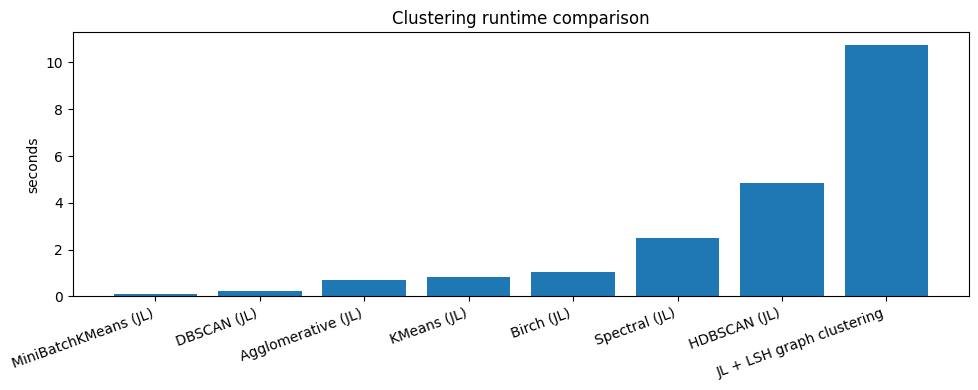

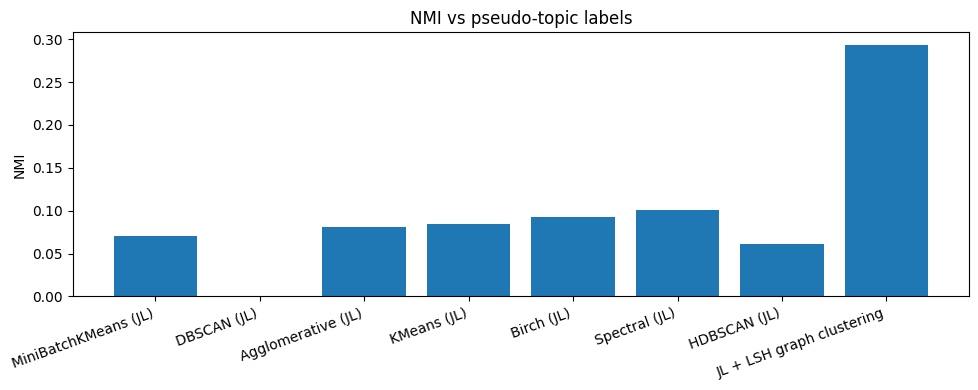

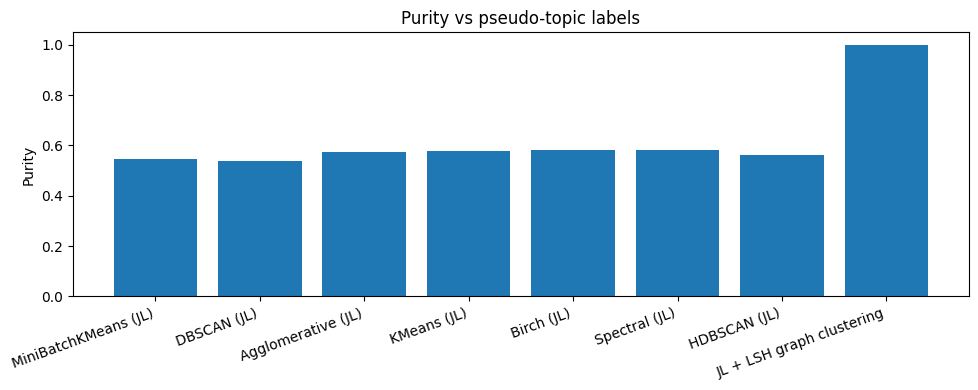

In [24]:
print("\n" + "=" * 80)
print("Clustering comparison...")
print("=" * 80)

df_small = df_articles.iloc[:EVAL_ARTICLES_SMALL].copy()
y_small = df_small["topic_id"].values

X_small_tfidf = X_tfidf[:EVAL_ARTICLES_SMALL]
X_small_jl = X_jl_main[:EVAL_ARTICLES_SMALL]
X_small_dense_for_spectral = X_small_jl

lsh_small = lsh_build_graph(X_small_jl, cosine_threshold=0.72, n_bits=128, band_size=4, max_bucket_size=250, seed=42)
y_lsh_small = lsh_small["labels"]

cluster_rows = []

def evaluate_clustering(method_name, X_dense, labels, y_true=None, runtime_sec=np.nan):
    metrics = safe_intrinsic_metrics(X_dense, labels)
    row = {
        "method": method_name,
        "time_sec": runtime_sec,
        "n_clusters": len(np.unique(labels)),
        "silhouette": metrics["silhouette"],
        "davies_bouldin": metrics["davies_bouldin"],
        "calinski_harabasz": metrics["calinski_harabasz"]
    }
    if y_true is not None:
        row["ARI"] = adjusted_rand_score(y_true, labels)
        row["NMI"] = normalized_mutual_info_score(y_true, labels)
        row["Purity"] = purity_score(y_true, labels)
    else:
        row["ARI"] = np.nan
        row["NMI"] = np.nan
        row["Purity"] = np.nan
    return row

t0 = time.perf_counter()
kmeans = KMeans(n_clusters=len(np.unique(y_small)), n_init=10, random_state=42)
y_km = kmeans.fit_predict(X_small_jl)
km_time = time.perf_counter() - t0
cluster_rows.append(evaluate_clustering("KMeans (JL)", X_small_jl, y_km, y_small, km_time))

t0 = time.perf_counter()
mbk = MiniBatchKMeans(n_clusters=len(np.unique(y_small)), batch_size=512, n_init=10, random_state=42)
y_mbk = mbk.fit_predict(X_small_jl)
mbk_time = time.perf_counter() - t0
cluster_rows.append(evaluate_clustering("MiniBatchKMeans (JL)", X_small_jl, y_mbk, y_small, mbk_time))

t0 = time.perf_counter()
birch = Birch(n_clusters=len(np.unique(y_small)), threshold=0.5)
y_birch = birch.fit_predict(X_small_jl)
birch_time = time.perf_counter() - t0
cluster_rows.append(evaluate_clustering("Birch (JL)", X_small_jl, y_birch, y_small, birch_time))

t0 = time.perf_counter()
agg = AgglomerativeClustering(n_clusters=len(np.unique(y_small)), metric="euclidean", linkage="ward")
y_agg = agg.fit_predict(X_small_jl)
agg_time = time.perf_counter() - t0
cluster_rows.append(evaluate_clustering("Agglomerative (JL)", X_small_jl, y_agg, y_small, agg_time))

try:
    t0 = time.perf_counter()
    spectral = SpectralClustering(
        n_clusters=len(np.unique(y_small)),
        affinity="nearest_neighbors",
        n_neighbors=15,
        random_state=42,
        assign_labels="kmeans"
    )
    y_spec = spectral.fit_predict(X_small_dense_for_spectral)
    spec_time = time.perf_counter() - t0
    cluster_rows.append(evaluate_clustering("Spectral (JL)", X_small_jl, y_spec, y_small, spec_time))
except Exception as e:
    print("Spectral clustering failed:", e)

t0 = time.perf_counter()
dbscan = DBSCAN(eps=0.75, min_samples=5, metric="euclidean")
y_db = dbscan.fit_predict(X_small_jl)
db_time = time.perf_counter() - t0
cluster_rows.append(evaluate_clustering("DBSCAN (JL)", X_small_jl, y_db, y_small, db_time))

if HDBSCAN_AVAILABLE:
    t0 = time.perf_counter()
    hdb = hdbscan.HDBSCAN(min_cluster_size=12, min_samples=4, metric="euclidean")
    y_hdb = hdb.fit_predict(X_small_jl)
    hdb_time = time.perf_counter() - t0
    cluster_rows.append(evaluate_clustering("HDBSCAN (JL)", X_small_jl, y_hdb, y_small, hdb_time))

cluster_rows.append(
    evaluate_clustering("JL + LSH graph clustering", X_small_jl, y_lsh_small, y_small, lsh_small["total_time_sec"])
)

cluster_df = pd.DataFrame(cluster_rows).sort_values("time_sec")
print(cluster_df)

plot_bar(cluster_df, "method", "time_sec", "Clustering runtime comparison", ylabel="seconds", rot=20, figsize=(10, 4))
plot_bar(cluster_df, "method", "NMI", "NMI vs pseudo-topic labels", ylabel="NMI", rot=20, figsize=(10, 4))
plot_bar(cluster_df, "method", "Purity", "Purity vs pseudo-topic labels", ylabel="Purity", rot=20, figsize=(10, 4))


# Duplicate-Detection on Pair Discovery


Duplicate-pair discovery experiment...
                    method  time_sec  candidate_pairs  precision  recall   f1  \
0   Exact all-pairs cosine  0.438374         10122750        0.0     0.0  0.0   
1  JL + LSH pair discovery  9.481872          3184026        0.0     0.0  0.0   

   tp  fp  fn  
0   0  70   0  
1   0  68   0  


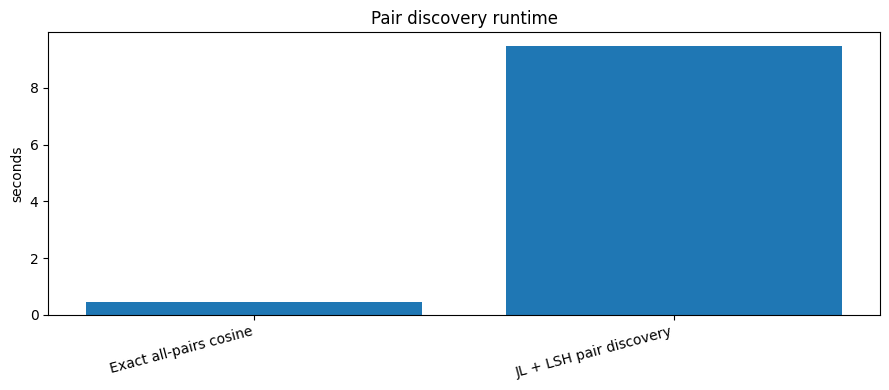

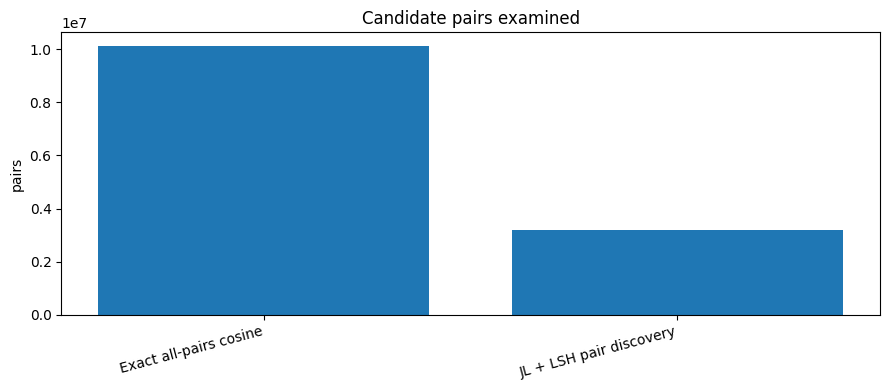

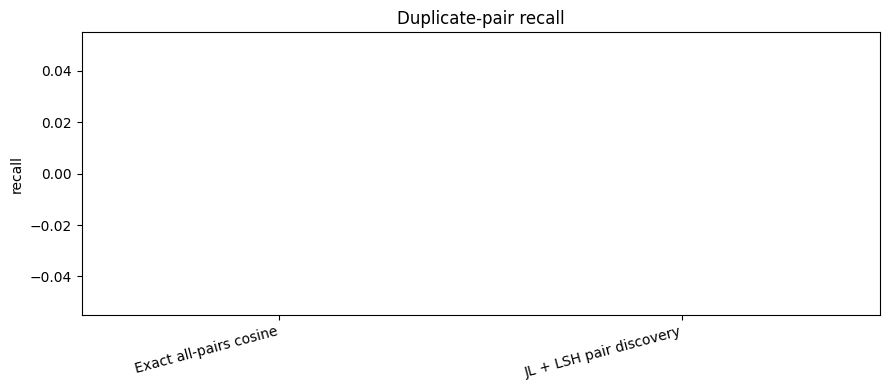

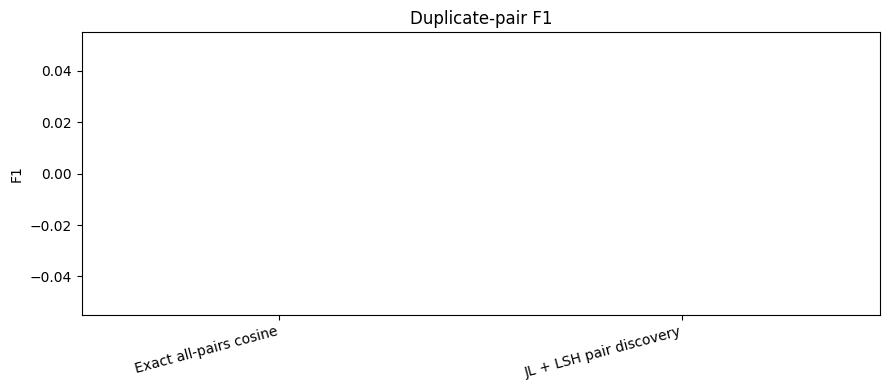

In [25]:
print("\n" + "=" * 80)
print("Duplicate-pair discovery experiment...")
print("=" * 80)

df_mix = pd.concat([
    df_articles[["doc_id", "title", "text", "topic", "topic_id"]].assign(kind="original"),
    pd.DataFrame({
        "doc_id": np.arange(len(df_articles), len(df_articles) + len(dup_df)),
        "title": dup_df["source_title"] + " [duplicate]",
        "text": dup_df["dup_text"],
        "topic": dup_df["topic"],
        "topic_id": dup_df["topic"].map(topic_to_id),
        "kind": "duplicate"
    })
], ignore_index=True)

X_mix = vectorizer.transform(df_mix["text"])
X_mix = normalize(X_mix, norm="l2", axis=1)

rp_mix = SparseRandomProjection(n_components=MAIN_JL_DIM, dense_output=True, random_state=42)
X_mix_jl = rp_mix.fit_transform(X_mix)
X_mix_jl = normalize(X_mix_jl, norm="l2", axis=1)

positive_pairs = set()
for i, row in dup_df.reset_index(drop=True).iterrows():
    orig = int(row["source_doc_id"])
    dup = int(len(df_articles) + i)
    positive_pairs.add((min(orig, dup), max(orig, dup)))

M = min(len(df_mix), 4500)
X_mix_small = X_mix_jl[:M]
n_mix_small = X_mix_small.shape[0]

def exact_pair_graph(X_dense, cosine_threshold=0.72):
    t0 = time.perf_counter()
    S = cosine_similarity(X_dense)
    np.fill_diagonal(S, 0)
    pairs = set()
    rows, cols = np.where(S >= cosine_threshold)
    for i, j in zip(rows, cols):
        if i < j:
            pairs.add((i, j))
    dt = time.perf_counter() - t0
    return pairs, dt

def evaluate_pair_discovery(pred_pairs, gt_pairs):
    pred_pairs = set(pred_pairs)
    gt_pairs = set(gt_pairs)
    tp = len(pred_pairs & gt_pairs)
    fp = len(pred_pairs - gt_pairs)
    fn = len(gt_pairs - pred_pairs)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-12)
    return {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn
    }

gt_pairs_small = set([(i, j) for (i, j) in positive_pairs if i < M and j < M])

exact_pairs, exact_pairs_time = exact_pair_graph(X_mix_small, cosine_threshold=0.72)
exact_pair_metrics = evaluate_pair_discovery(exact_pairs, gt_pairs_small)

lsh_pairs_out = lsh_build_graph(X_mix_small, cosine_threshold=0.72, n_bits=128, band_size=4, max_bucket_size=250, seed=42)
lsh_pairs = set(lsh_pairs_out["edges"])
lsh_pair_metrics = evaluate_pair_discovery(lsh_pairs, gt_pairs_small)

pair_df = pd.DataFrame([
    {
        "method": "Exact all-pairs cosine",
        "time_sec": exact_pairs_time,
        "candidate_pairs": (M * (M - 1)) // 2,
        **exact_pair_metrics
    },
    {
        "method": "JL + LSH pair discovery",
        "time_sec": lsh_pairs_out["total_time_sec"],
        "candidate_pairs": lsh_pairs_out["n_candidates"],
        **lsh_pair_metrics
    }
])
print(pair_df)

plot_bar(pair_df, "method", "time_sec", "Pair discovery runtime", ylabel="seconds", rot=15)
plot_bar(pair_df, "method", "candidate_pairs", "Candidate pairs examined", ylabel="pairs", rot=15)
plot_bar(pair_df, "method", "recall", "Duplicate-pair recall", ylabel="recall", rot=15)
plot_bar(pair_df, "method", "f1", "Duplicate-pair F1", ylabel="F1", rot=15)

# Space Complexity Summary


Storage summary...
                             representation  memory_mb
0                                  Raw text  24.276352
1                             Sparse TF-IDF  19.934181
2                       JL dense (512 dims)  46.875000
3  LSH bits (packed as bool array estimate)   1.464844


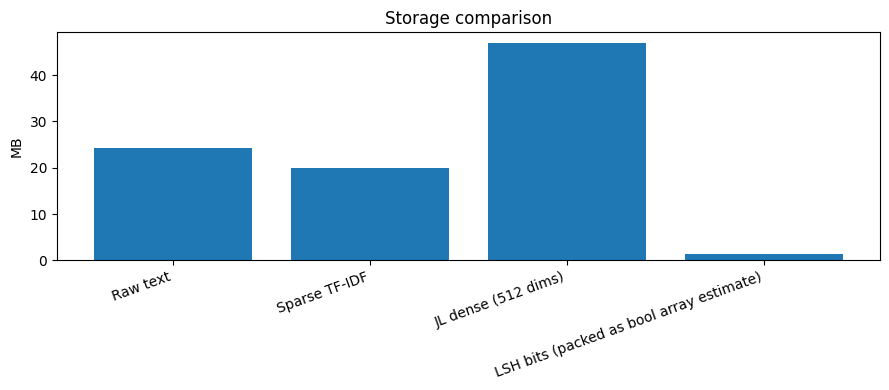

In [26]:
print("\n" + "=" * 80)
print("Storage summary...")
print("=" * 80)

storage_rows = [
    {
        "representation": "Raw text",
        "memory_mb": text_memory_bytes(df_articles["text"].tolist()) / (1024**2)
    },
    {
        "representation": "Sparse TF-IDF",
        "memory_mb": vector_memory_bytes(X_tfidf) / (1024**2)
    },
    {
        "representation": f"JL dense ({MAIN_JL_DIM} dims)",
        "memory_mb": vector_memory_bytes(X_jl_main) / (1024**2)
    },
    {
        "representation": "LSH bits (packed as bool array estimate)",
        "memory_mb": lsh_index["bits"].nbytes / (1024**2)
    },
]
storage_df = pd.DataFrame(storage_rows)
print(storage_df)
plot_bar(storage_df, "representation", "memory_mb", "Storage comparison", ylabel="MB", rot=20)


# Scaling Experiments


Scaling experiments...


LSH retrieval top-1:   0%|          | 0/250 [00:00<?, ?it/s]

LSH retrieval top-1:   0%|          | 0/500 [00:00<?, ?it/s]

LSH retrieval top-1:   0%|          | 0/1000 [00:00<?, ?it/s]

LSH retrieval top-1:   0%|          | 0/1200 [00:00<?, ?it/s]

   n_docs  jl_transform_sec  exact_top1_sec  lsh_top1_sec  lsh_avg_candidates  \
0    2000          0.566952        0.025626      0.430620              1200.0   
1    4000          0.352124        0.073079      1.169886              1200.0   
2    8000          0.380222        0.271881      4.100347              1200.0   
3   12000          0.422865        0.502059     13.794934              1200.0   

   jl_memory_mb  
0        7.8125  
1       15.6250  
2       31.2500  
3       46.8750  


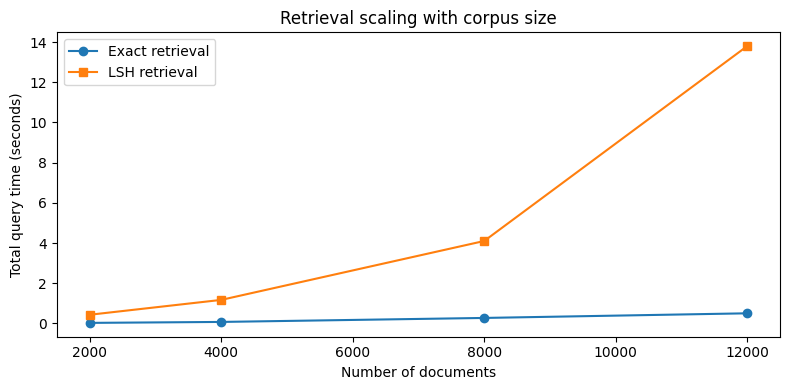

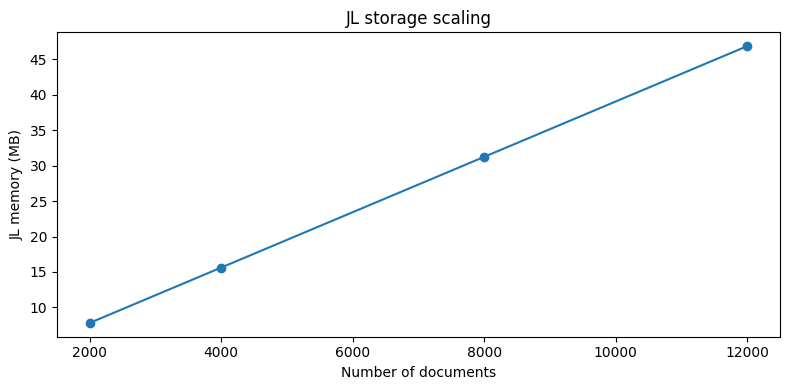

In [27]:
print("\n" + "=" * 80)
print("Scaling experiments...")
print("=" * 80)

scale_sizes = [2000, 4000, 8000, min(12000, len(df_articles))]
scale_rows = []

for n_docs in scale_sizes:
    Xn = X_tfidf[:n_docs]
    dupn = X_dup_tfidf[:min(len(dup_df), max(200, n_docs // 8))]

    rp = SparseRandomProjection(n_components=MAIN_JL_DIM, dense_output=True, random_state=42)
    t0 = time.perf_counter()
    Xn_jl = rp.fit_transform(Xn)
    jl_t = time.perf_counter() - t0
    Xn_jl = normalize(Xn_jl, norm="l2", axis=1)

    dupn_jl = rp.transform(dupn)
    dupn_jl = normalize(dupn_jl, norm="l2", axis=1)

    t0 = time.perf_counter()
    nn = NearestNeighbors(metric="cosine", algorithm="brute").fit(Xn_jl)
    d, inds = nn.kneighbors(dupn_jl, n_neighbors=1)
    exact_t = time.perf_counter() - t0

    idx = build_lsh_index_for_retrieval(Xn_jl, n_bits=LSH_BITS, band_size=LSH_BAND_SIZE, seed=42)
    preds, qtimes, csizes = lsh_retrieve_topk(Xn_jl, idx, dupn_jl, topk=1, band_size=LSH_BAND_SIZE, max_candidates=1200)
    lsh_t = np.sum(qtimes)

    scale_rows.append({
        "n_docs": n_docs,
        "jl_transform_sec": jl_t,
        "exact_top1_sec": exact_t,
        "lsh_top1_sec": lsh_t,
        "lsh_avg_candidates": np.mean(csizes),
        "jl_memory_mb": vector_memory_bytes(Xn_jl) / (1024**2)
    })

scale_df = pd.DataFrame(scale_rows)
print(scale_df)

plt.figure(figsize=(8, 4))
plt.plot(scale_df["n_docs"], scale_df["exact_top1_sec"], marker="o", label="Exact retrieval")
plt.plot(scale_df["n_docs"], scale_df["lsh_top1_sec"], marker="s", label="LSH retrieval")
plt.xlabel("Number of documents")
plt.ylabel("Total query time (seconds)")
plt.title("Retrieval scaling with corpus size")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(scale_df["n_docs"], scale_df["jl_memory_mb"], marker="o")
plt.xlabel("Number of documents")
plt.ylabel("JL memory (MB)")
plt.title("JL storage scaling")
plt.tight_layout()
plt.show()

# Qualitative Examples

In [28]:
print("\n" + "=" * 80)
print("Qualitative retrieval examples...")
print("=" * 80)

def show_retrieval_examples(num_examples=12):
    chosen = np.linspace(0, len(dup_df)-1, num=num_examples, dtype=int)
    rows = []
    for i in chosen:
        source_id = dup_df.iloc[i]["source_doc_id"]
        source_title = df_articles.iloc[source_id]["title"]
        hardness = dup_df.iloc[i]["hardness"]

        pred_exact = exact_jl_preds[i][0]
        pred_lsh = lsh_preds[i][0] if len(lsh_preds[i]) > 0 else None

        rows.append({
            "dup_idx": i,
            "hardness": hardness,
            "source_title": source_title,
            "exact_top1_title": df_articles.iloc[pred_exact]["title"] if pred_exact is not None else None,
            "exact_hit": int(pred_exact == source_id),
            "lsh_top1_title": df_articles.iloc[pred_lsh]["title"] if pred_lsh is not None else None,
            "lsh_hit": int(pred_lsh == source_id) if pred_lsh is not None else 0,
        })
    return pd.DataFrame(rows)

examples_df = show_retrieval_examples(15)
print(examples_df)

for ex_idx in [0, 1, 2]:
    print("\n" + "-" * 80)
    print(f"Example duplicate #{ex_idx}")
    src_id = dup_df.iloc[ex_idx]["source_doc_id"]
    print("Source title:", df_articles.iloc[src_id]["title"])
    print("Hardness:", dup_df.iloc[ex_idx]["hardness"])
    print("Source snippet:", df_articles.iloc[src_id]["text"][:450], "...")
    print("Duplicate snippet:", dup_df.iloc[ex_idx]["dup_text"][:450], "...")
    print("Exact top-1:", df_articles.iloc[exact_jl_preds[ex_idx][0]]["title"])
    if len(lsh_preds[ex_idx]) > 0:
        print("LSH top-1:", df_articles.iloc[lsh_preds[ex_idx][0]]["title"])
    else:
        print("LSH top-1: No candidate found")


Qualitative retrieval examples...
    dup_idx hardness                                       source_title  \
0         0     easy                                Hindu denominations   
1        85   medium                                 Tolata, Cochabamba   
2       171     easy           The Juridification of Resource Conflicts   
3       256   medium                                 Caroline de Valory   
4       342     easy                           Pat Moylan (Cork hurler)   
5       428     hard  Odisha Industrial Infrastructure Development C...   
6       513     easy                                      Ernest Gaudin   
7       599     hard                                   South Hurstville   
8       685   medium                                    Corpus Mysticum   
9       770     hard  Detroit Film Critics Society Award for Best Do...   
10      856   medium                                   Mostafa El Gamel   
11      942     easy                                         Skhu

# 2 D Visualization


2D visualization...


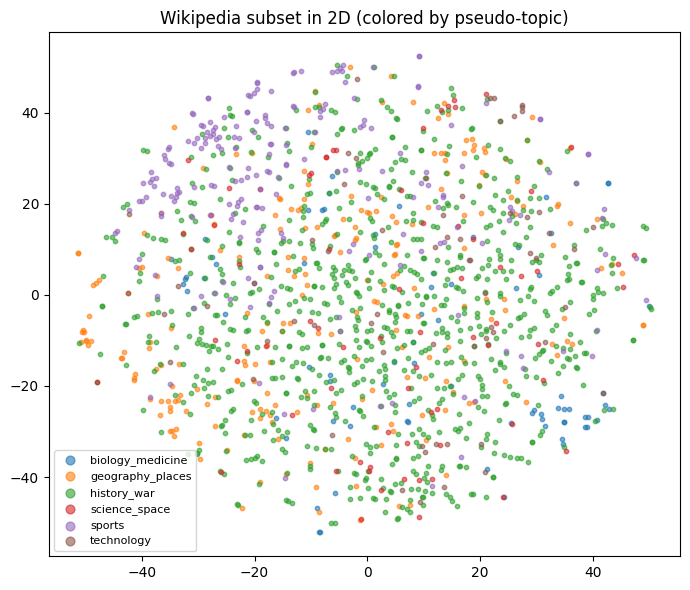

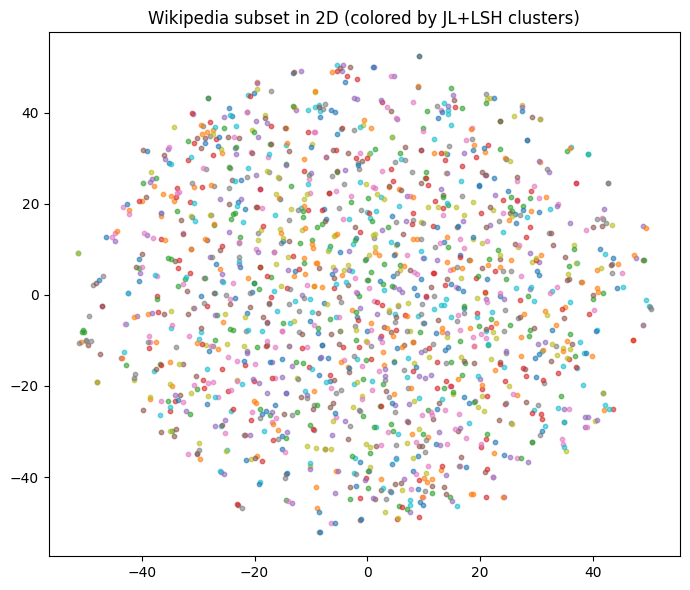

In [29]:
print("\n" + "=" * 80)
print("2D visualization...")
print("=" * 80)

viz_n = min(1500, X_small_jl.shape[0])
X_viz = X_small_jl[:viz_n]
y_viz = y_small[:viz_n]
labels_viz = y_lsh_small[:viz_n]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="random", learning_rate="auto")
X_2d = tsne.fit_transform(X_viz)

plt.figure(figsize=(7, 6))
for c in np.unique(y_viz):
    idx = np.where(y_viz == c)[0]
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=10, alpha=0.6, label=list(topic_to_id.keys())[c])
plt.title("Wikipedia subset in 2D (colored by pseudo-topic)")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for c in np.unique(labels_viz):
    idx = np.where(labels_viz == c)[0]
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=10, alpha=0.6)
plt.title("Wikipedia subset in 2D (colored by JL+LSH clusters)")
plt.tight_layout()
plt.show()

# Final Summary Tables

In [30]:
summary_rows = []

for method in retrieval_df["method"].unique():
    sub = retrieval_df[(retrieval_df["method"] == method) & (retrieval_df["topk"] == 1)].iloc[0]
    summary_rows.append({
        "section": "retrieval",
        "method": method,
        "main_score_name": "Recall@1",
        "main_score": sub["recall"],
        "runtime_sec": sub["avg_query_time_ms"] / 1000.0,
        "notes": f"avg_candidates={sub['avg_candidates']:.2f}"
    })

for _, row in cluster_df.iterrows():
    summary_rows.append({
        "section": "clustering",
        "method": row["method"],
        "main_score_name": "NMI",
        "main_score": row["NMI"],
        "runtime_sec": row["time_sec"],
        "notes": f"clusters={row['n_clusters']}"
    })

for _, row in pair_df.iterrows():
    summary_rows.append({
        "section": "pair_discovery",
        "method": row["method"],
        "main_score_name": "F1",
        "main_score": row["f1"],
        "runtime_sec": row["time_sec"],
        "notes": f"candidates={row['candidate_pairs']}"
    })

summary_df = pd.DataFrame(summary_rows)
print("\nFINAL SUMMARY")
print(summary_df)


FINAL SUMMARY
           section                     method main_score_name  main_score  \
0        retrieval     Exact cosine on TF-IDF        Recall@1    0.999167   
1        retrieval         Exact cosine on JL        Recall@1    1.000000   
2        retrieval         JL + LSH retrieval        Recall@1    0.111667   
3       clustering       MiniBatchKMeans (JL)             NMI    0.070949   
4       clustering                DBSCAN (JL)             NMI    0.000000   
5       clustering         Agglomerative (JL)             NMI    0.081081   
6       clustering                KMeans (JL)             NMI    0.084577   
7       clustering                 Birch (JL)             NMI    0.092304   
8       clustering              Spectral (JL)             NMI    0.100499   
9       clustering               HDBSCAN (JL)             NMI    0.060758   
10      clustering  JL + LSH graph clustering             NMI    0.293275   
11  pair_discovery     Exact all-pairs cosine              F1

# Save Output Tables

In [31]:
os.makedirs("ma5770_wikipedia_outputs", exist_ok=True)

save_df(df_articles, "ma5770_wikipedia_outputs/articles_sample.csv")
save_df(dup_df, "ma5770_wikipedia_outputs/duplicates.csv")
save_df(jl_df, "ma5770_wikipedia_outputs/jl_validation.csv")
save_df(retrieval_df, "ma5770_wikipedia_outputs/retrieval_results.csv")
save_df(hardness_df, "ma5770_wikipedia_outputs/retrieval_by_hardness.csv")
save_df(cluster_df, "ma5770_wikipedia_outputs/clustering_results.csv")
save_df(pair_df, "ma5770_wikipedia_outputs/pair_discovery_results.csv")
save_df(storage_df, "ma5770_wikipedia_outputs/storage_summary.csv")
save_df(scale_df, "ma5770_wikipedia_outputs/scaling_results.csv")
save_df(examples_df, "ma5770_wikipedia_outputs/qualitative_examples.csv")
save_df(summary_df, "ma5770_wikipedia_outputs/final_summary.csv")

print("\nSaved outputs under ma5770_wikipedia_outputs/")


Saved outputs under ma5770_wikipedia_outputs/
